## **Image Prediction**

### Imports

In [3]:
import sys
import os
sys.path.append(os.path.abspath(".."))

In [4]:
import torch
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
from src.model import WaterQualityResNet18

### Load Model

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Load Model Architecture
model = WaterQualityResNet18(num_classes=3, pretrained=True, freeze_backbone=False)

# Load Trained weights
model.load_state_dict(torch.load('../artifacts/best_model.pth', map_location=device))

model = model.to(device)
model.eval()

class_names = ['clean', 'muddy', 'polluted']

### Prediction Function

In [12]:
def predict_image(image_path):

    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor()
    ])

    img = Image.open(image_path).convert('RGB')
    img_tensor = transform(img).unsqueeze(0).to(device)

    # prediction
    with torch.no_grad():
        output = model(img_tensor)
        probabilities = torch.softmax(output, dim=1)
        confidence, predicted = torch.max(probabilities, 1)

    predicted_class = class_names[predicted.item()]
    confidence = confidence.item() * 100

    # show 
    plt.imshow(img)
    plt.axis('off')


    colors = {'clean' : 'green',
              'muddy' : 'orange',
              'polluted' : 'red'}
    
    plt.title(f"{predicted_class.upper()} ({confidence:.2f}%)",
              color = colors[predicted_class],
              fontsize=12,
              fontweight='bold')
    
    plt.show()

    print(f"Prediction: {predicted_class}")
    print(f"Confidence: {confidence:.2f}%")

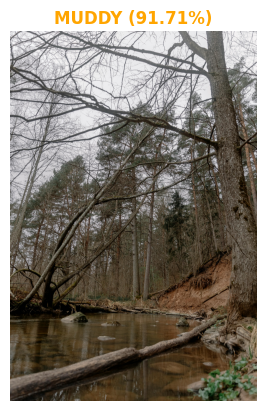

Prediction: muddy
Confidence: 91.71%


In [13]:
predict_image('../data/split_dataset/test/muddy/muddy17.jpg')